## Сессия 5 - Статистика и выбросы

In [1]:
import pandas as pd

data = pd.read_csv('data_from_notes/full_data.csv', sep = ';')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92037 entries, 0 to 92036
Data columns (total 46 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       92037 non-null  object 
 1   customer_id                    92037 non-null  object 
 2   order_status                   92037 non-null  object 
 3   order_purchase_timestamp       92037 non-null  object 
 4   order_approved_at              92025 non-null  object 
 5   order_delivered_carrier_date   91041 non-null  object 
 6   order_delivered_customer_date  90062 non-null  object 
 7   order_estimated_delivery_date  92037 non-null  object 
 8   is_delivered                   92037 non-null  bool   
 9   customer_unique_id             92037 non-null  object 
 10  customer_zip_code_prefix       92037 non-null  int64  
 11  customer_city                  92037 non-null  object 
 12  customer_state                 92037 non-null 

**Для дальнейшей работы необходимо провести проведение типов данных в столбцах, содержащих даты и удалить технические флаги из датафрейма**

In [2]:
cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'shipping_limit_date', 'review_creation_date', 'review_answer_timestamp']
for col in cols:
    data[col] = pd.to_datetime(data[col], format = 'mixed')

# Удаляем техические флаги
data.drop(columns = ['is_delivered', 'confirm', 'conf_&_paid'], inplace = True)

# Проврека датафрейма
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92037 entries, 0 to 92036
Data columns (total 43 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       92037 non-null  object        
 1   customer_id                    92037 non-null  object        
 2   order_status                   92037 non-null  object        
 3   order_purchase_timestamp       92037 non-null  datetime64[ns]
 4   order_approved_at              92025 non-null  datetime64[ns]
 5   order_delivered_carrier_date   91041 non-null  datetime64[ns]
 6   order_delivered_customer_date  90062 non-null  datetime64[ns]
 7   order_estimated_delivery_date  92037 non-null  datetime64[ns]
 8   customer_unique_id             92037 non-null  object        
 9   customer_zip_code_prefix       92037 non-null  int64         
 10  customer_city                  92037 non-null  object        
 11  customer_state 

**Краткая описательная статистика доставки**

In [3]:
# Создание колонки времени доставки для всех заказов
data['delivery_days'] = (data['order_delivered_customer_date'] - data['order_purchase_timestamp']).dt.days.astype('float32')

data['delivery_days'].describe()

count    90062.000000
mean        11.972952
std          9.429109
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        208.000000
Name: delivery_days, dtype: float64

**Поиск и подсчет выбросов времени доставки**

In [4]:
q1 = data['delivery_days'].quantile(0.25)
q3 = data['delivery_days'].quantile(0.75)

iqr = q3 - q1
lower_append = q1 - 1.5 * iqr
uppper_append = q3 + 1.5 * iqr

count_blowouts = (data['delivery_days'] < lower_append) | (data['delivery_days'] > uppper_append)
print(f"Количество выбросов в днях доставки: {count_blowouts.sum()}")
print(f"Количество выбросов во времени доставки в процентном соотношении: {count_blowouts.sum() / data['delivery_days'].count() * 100:.2f}%")


Количество выбросов в днях доставки: 4420
Количество выбросов во времени доставки в процентном соотношении: 4.91%


Количество выбросов во времени доставки достаточно велико и составляет 4.91% от всех доставленных заказов. Далее, необходимо выяснить, где находится основное количество этих выбросов

c:\Users\User\Analytics-Training\sprint2_olist\work_with_pandas\style.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


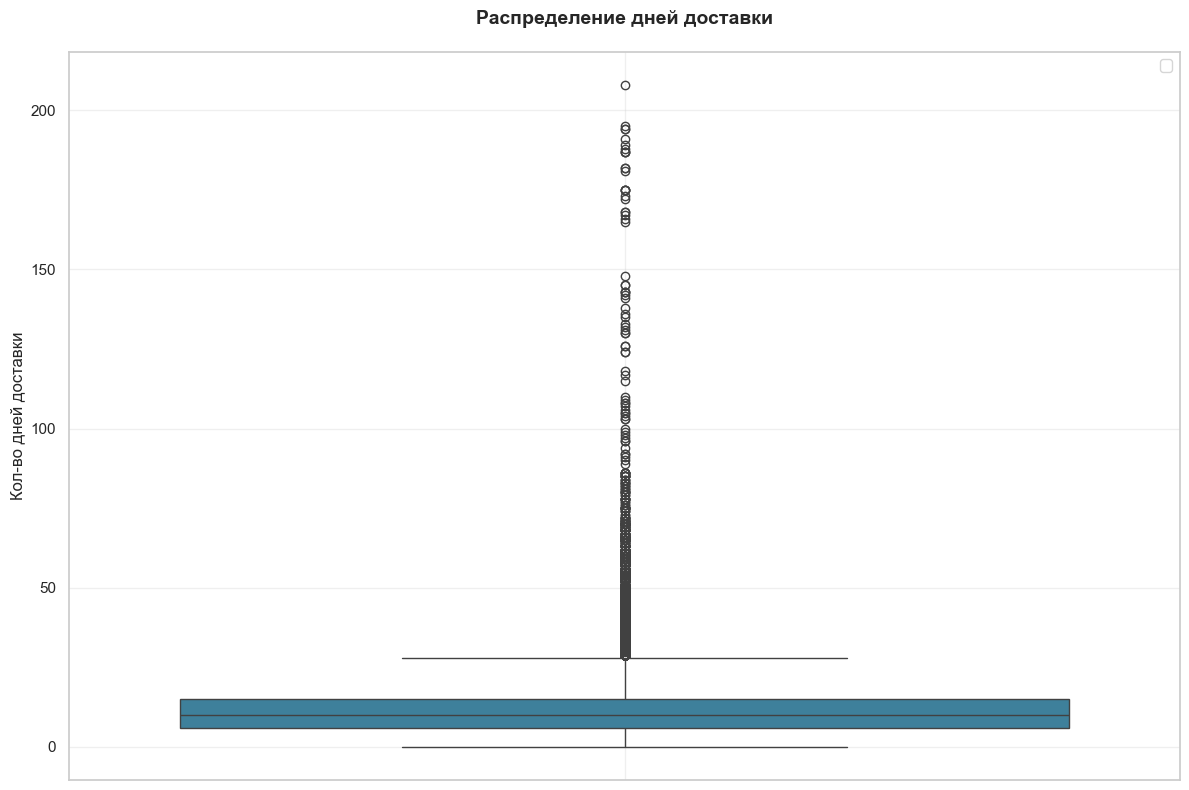

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from style import setup_style, decorate 
# Построим боксплот, которая сможет наглядно отразить распределение дней доставки
setup_style()
fig, ax = plt.subplots(figsize = (12, 8))
sns.boxplot(y = data['delivery_days'], ax = ax)
decorate(ax, 'Распределение дней доставки', '', 'Кол-во дней доставки')
plt.tight_layout()
plt.savefig('plots/outlier_boxplot.png', dpi = 300)
plt.show()

Все выбросы связаны со значительным превышение дней доставки. Необходим, насколько возможно, выяснить с чем связано такое большое время доставки

In [6]:
# Нахождение общих признаков у выбросов
# Создание датафрейма, содержащего только выбросы
blowouts = data[count_blowouts].copy()

# Проверка дат у выбросов
print(f"Заказы из будущего: {(blowouts['order_purchase_timestamp'] > '2018-12-31').sum()}")

# Проверка статусов заказов
print(blowouts['order_status'].value_counts())

# Проверка географии выбросов
print(blowouts['customer_state'].value_counts())

# Какая средняя оценка у отзывов на заказы с выбросами
print(f"\nСредняя оценка заказов: {blowouts['review_score'].mean().round(2)}")

# На каком этапе происходит задержка доставки?
blowouts['approve_days'] = (blowouts['order_approved_at'] - blowouts['order_purchase_timestamp']).dt.days # Время прошедшее с момента совершения оплаты до подтверждения заказа
blowouts['seller_days'] = (blowouts['order_delivered_carrier_date'] - blowouts['order_approved_at']).dt.days # Время прошедшее с момента подтверждения заказа до отгрузки заказа поставщиком
blowouts['to_customer_days'] = (blowouts['order_delivered_customer_date'] - blowouts['order_delivered_carrier_date']).dt.days # Время прошедшее с момента отгрузки заказа поставщиком до доставки покупателю

print(f"\n{blowouts[['approve_days', 'seller_days', 'to_customer_days']].describe()}")

Заказы из будущего: 0
order_status
delivered    4418
canceled        2
Name: count, dtype: int64
customer_state
RJ    1092
SP     501
BA     408
RS     333
MG     264
SC     207
PA     199
CE     178
PE     161
PR     125
MA     113
AL     105
ES     103
GO      91
PB      81
RN      68
MT      66
DF      58
SE      57
AM      53
PI      43
MS      35
RO      28
AP      15
TO      14
RR      14
AC       8
Name: count, dtype: int64

Средняя оценка заказов: 2.34

       approve_days  seller_days  to_customer_days
count   4420.000000  4419.000000       4419.000000
mean       0.374887     6.475900         32.546956
std        1.317095     9.148196         18.341987
min        0.000000    -5.000000          0.000000
25%        0.000000     1.000000         26.000000
50%        0.000000     3.000000         30.000000
75%        0.000000     7.000000         37.000000
max       30.000000   125.000000        205.000000


**Инсайт по данным:** Выбросы связаны не с ошибками данных, а с реальными проблемами логистике, которые распостранены по всей Бразилии. Наибольшее количество выбросов в Рио-Де-Жанейро и Сан-Паулу говорит о том, что отдаленность регионов не играет никакой роли, так как наибольшее количество выбросов фиксируется в крупных и одними из наиболее развитых штатах. 

При исследовании было выявлено, что сама площадка Olist обрабатывает и передает заказ весьма быстро, что подтверждается средним значением, которое составляет менее одного дня. Настоящая катастрофа происходит на этапе доставки заказа непосредственно клиенту - Среднее значение 32 дня, при этом среднеквадратическое отклонение составляет 18 дней, что говорит о том, что время доставки очень и очень нестабильно и только 50% заказов преодолевают данный этап менее, чем за месяц.

**Рекомендации:** Необходимо в срочном порядке провести работу с логистической компанией, осуществляющей доставку товаров до клиента или сменить её, так как это играет в большой минус самой площадке, это подтверждает средняя оценка подобных заказов: 2.34, что является крайне низким показателем.

**Анализ рисков по штатам**

In [7]:
# Для чистоты данных выбросы будут удалены. Датафрейм, содержащий выбросы будует выгружен в отдельный CSV файл.
blowouts.to_csv('data_from_notes/blowouts.csv', sep = ';', index = False)

conf_data = data[~count_blowouts].copy()
conf_data.to_csv('data_from_notes/outlier_free_data.csv', index = False, encoding = 'utf-8', sep = ';')

grouped_for_state = conf_data.groupby('customer_state')['delivery_days'].describe()
print(grouped_for_state)
print()
print(f"90-я квантиль:\n{conf_data.groupby('customer_state')['delivery_days'].quantile(0.9)}")



                  count       mean       std  min    25%   50%    75%   max
customer_state                                                             
AC                 66.0  16.515152  4.564892  7.0  13.25  16.0  19.00  28.0
AL                246.0  17.670732  5.519660  5.0  14.00  17.5  22.00  28.0
AM                 82.0  19.707317  6.634157  4.0  14.00  22.0  25.00  28.0
AP                 43.0  20.720930  5.708497  5.0  18.00  22.0  25.00  28.0
BA               2706.0  15.513674  5.690723  2.0  11.00  15.0  20.00  28.0
CE                959.0  16.374348  5.662065  2.0  12.00  16.0  20.00  28.0
DF               1887.0  11.645469  5.512344  1.0   7.00  11.0  15.00  28.0
ES               1722.0  13.540650  5.581039  2.0   9.00  13.0  17.00  28.0
GO               1751.0  13.582524  5.438585  1.0  10.00  13.0  17.00  28.0
MA                546.0  17.353479  5.372848  3.0  14.00  17.0  22.00  28.0
MG              10256.0  10.791732  5.262486  1.0   7.00  10.0  14.00  28.0
MS          

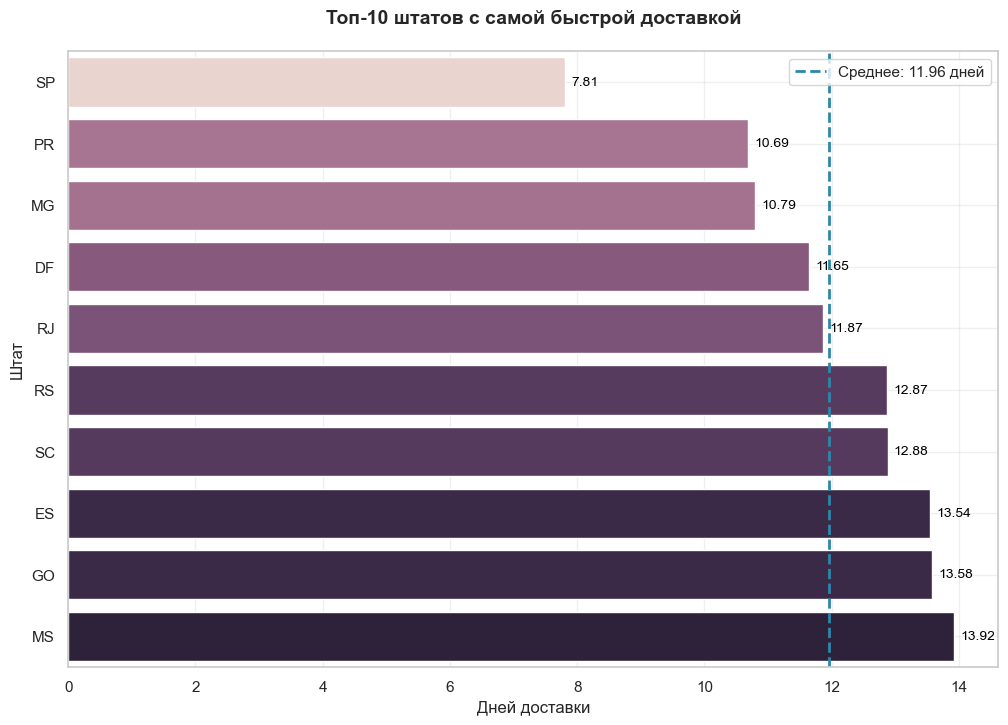

Среднее время доставки среди топовых штатов: 11.959250354766846

Среднее значение среднеквадратического отклонения среди топовых штатов: 5.504880475997925

Штат с самым долгим среднем временем доставки: count    43.000000
mean     20.720930
std       5.708497
min       5.000000
25%      18.000000
50%      22.000000
75%      25.000000
max      28.000000
Name: AP, dtype: float64



<Figure size 1000x600 with 0 Axes>

In [14]:
from style import setup_style, decorate 
# Построим гистограмму топ-10 штатов с наиболее быстрой доставкой
top_states = grouped_for_state.sort_values('mean', ascending = True).head(10)

setup_style()
fig, ax = plt.subplots(figsize = (12, 8))
sns.barplot(data = top_states, x = 'mean', y = 'customer_state', hue = 'mean', legend = False, ax = ax)
# Для лучшей читаемости добавим конкретные значения каждому столбцу.
for i, v in enumerate(top_states['mean'].values):
    plt.text(
        v + 0.1, i, f'{v:.2f}', va = 'center', fontsize = 10, color = 'black'
    )
# Также, добавим линию среднего среди всех штатов, для наглядности сравнения
plt.axvline(x = top_states['mean'].mean(), linewidth = 2, linestyle = '--', label = f'Среднее: {top_states["mean"].mean():.2f} дней')
decorate(ax, 'Топ-10 штатов с самой быстрой доставкой', 'Дней доставки', 'Штат')
plt.show()
plt.savefig('plots/top_states', dpi = 300)
print(f"Среднее время доставки среди топовых штатов: {top_states['mean'].mean()}\n")
print(f"Среднее значение среднеквадратического отклонения среди топовых штатов: {top_states['std'].mean()}\n")
print(f"Штат с самым долгим среднем временем доставки: {grouped_for_state.loc[grouped_for_state['mean'].idxmax()]}\n")

**Вывод по полученным данным:** После исключения выбросов картина стала более стабильной, среднее время доставки составило 12 дней, а среднеквадратическое отклонение в среднем составило 5.5 дней. Такие показатели абсолютно нормальны, учитывая специфику Бразилии и развитие логистики в этой стране. Стоит отметить, что в наиболее разивитом штате - Сан-Паулу время доставки сокращается в среднем до 7 дней, а самая долгая доставка среди штатов наблюдается в штатае Амапа, расположенном на крайнем севере. Среднее время доставки в нем достигает 20 дней, что гораздо дольше средней доставки в Сан-Паулу, что говорит о том, что в зависимости от местонахождения покупателя время доставки может очень разнится. Для исправления данной проблемы и уменьшения среднего времени доставки во всех штатах **рекомендуется** провести работу со службой доставки, дополнительно проработать и, возможно, переработать логистические маршрурты. Также, как показывают данные, существует острая проблема размещения складов в разных регионах и разных частях страны, так как среднее время доставке в разных штатах может значительно отличаться. Необходимо проработать стратегию развития складов для увеличения комфорта пользователей.